# **Quantum Second Preimage Finder**

Given a known input string `a` and its hash `ha = H(a)`,
find a different string `b` such that `H(b) = ha`.

This demonstrates a second preimage attack using **Grover's** algorithm.

Hash function (3-input bits → 2 output bits):
```
H(x2, x1, x0):
- h0 = x0 XOR x1
- h1 = x1 AND x2
```
The oracle marks any `b (b ≠ a)` whose hash equals the fixed target `ha`.
Grover amplification boosts those marked states.

* **Goal:**  Given fixed `a` and `ha`, find `b`
* **Search space:** 3-qubit register `(b only)`
* **Oracle:** Marks States where `H(b) = ha` (fixed target)
* **Attack type:** Second preimage attack

In [1]:
!pip install qiskit -q
!pip install qiskit-aer -q
!pip install qiskit[visualization] -q
#!pip install qiskit-algorithms -q

# pip install qiskit-ibm-runtime
import qiskit
print("____ QISKIT VERSION____")
print(qiskit.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
____ QISKIT VERSION____
2.4.1


QUANTUM SECOND PREIMAGE FINDER
Hash: H(x2,x1,x0): h0 = x0⊕x1,  h1 = x1∧x2  (3-bit→2-bit)

  Known input  :  a  = 101 (5)
  Known hash   :  ha = 01 (1)
  Searching for:  b ≠ a  with H(b) = 01
  Valid targets:  ['001', '010']
  Grover iters :  2

── Circuit stats ──
  Qubits : 5
  Gates  : 63
  Depth  : 38
  Width  : 8

── Measurement results (4096 shots) ──

  ✅ Valid second preimages found (H(b) = 01, b ≠ a):
    b = 001 (1)   H(b) = 01    shots = 39  (1.0%)
    b = 010 (2)   H(b) = 01    shots = 26  (0.6%)

  ✅ Second-preimage shots : 65  (1.6%)
  ⚪ Self (b == a) shots  : 34  (0.8%)
  ❌ Non-matching shots   : 3997  (97.6%)

  🎯 Best answer: a = 101 and b = 001 both hash to 01

── Circuit diagram ──


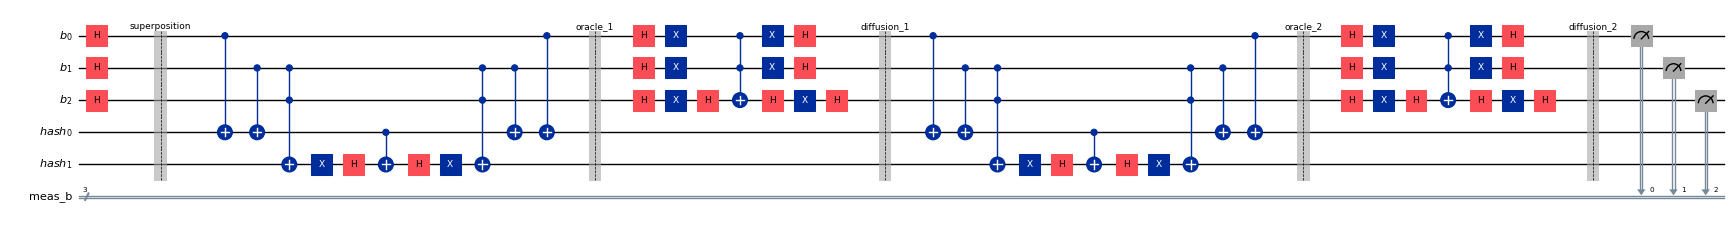

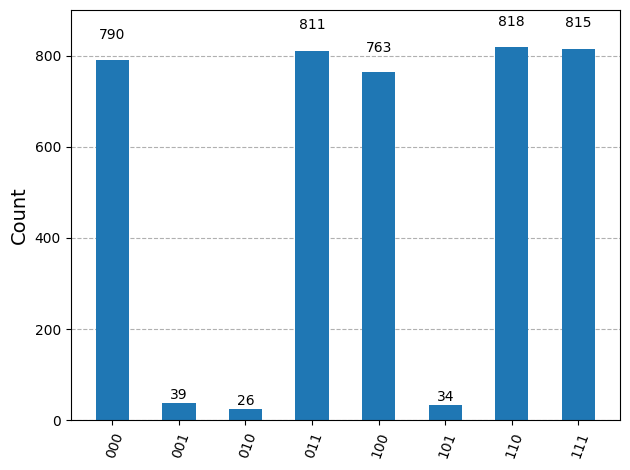

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from collections import defaultdict
import math

# ── 1. Classical hash function ───────────────────────────────────────────────

def toy_hash(x: int) -> int:
    '''
    Toy hash: 3-bit input → 2-bit output.
    h0 = x0 XOR x1
    h1 = x1 AND x2
    '''
    x0 = (x >> 0) & 1
    x1 = (x >> 1) & 1
    x2 = (x >> 2) & 1
    h0 = x0 ^ x1
    h1 = x1 & x2
    return (h1 << 1) | h0


# ── 2. Oracle: marks states |b⟩ where H(b) == target_hash ───────────────────

def build_target_hash_oracle(qc: QuantumCircuit,
                              b_qubits: list,
                              hash_qubits: list,
                              target_hash: int):
    '''
    Computes H(b) into hash_qubits, then phase-flips states where
    H(b) equals the fixed target_hash value.

    target_hash is a 2-bit integer (0–3).
    After the phase flip, H(b) is uncomputed (hash_qubits restored to |00⟩).
    '''
    # ── Compute H(b) into hash_qubits ────────────────────────────────────────
    # h0 = b0 XOR b1
    qc.cx(b_qubits[0], hash_qubits[0])
    qc.cx(b_qubits[1], hash_qubits[0])
    # h1 = b1 AND b2
    qc.ccx(b_qubits[1], b_qubits[2], hash_qubits[1])

    # ── Flip hash bits that should be 0 in the target ────────────────────────
    # After this, hash_qubits == |11⟩ iff H(b) == target_hash
    target_h0 = (target_hash >> 0) & 1
    target_h1 = (target_hash >> 1) & 1
    if target_h0 == 0:
        qc.x(hash_qubits[0])
    if target_h1 == 0:
        qc.x(hash_qubits[1])

    # ── Phase kickback: CZ on both hash bits ─────────────────────────────────
    # When both hash_qubits are |1⟩, flip the phase of |b⟩
    qc.h(hash_qubits[1])
    qc.cx(hash_qubits[0], hash_qubits[1])
    qc.h(hash_qubits[1])

    # ── Undo the target-bit flips ─────────────────────────────────────────────
    if target_h0 == 0:
        qc.x(hash_qubits[0])
    if target_h1 == 0:
        qc.x(hash_qubits[1])

    # ── Uncompute H(b) ────────────────────────────────────────────────────────
    qc.ccx(b_qubits[1], b_qubits[2], hash_qubits[1])
    qc.cx(b_qubits[1], hash_qubits[0])
    qc.cx(b_qubits[0], hash_qubits[0])


# ── 3. Grover diffusion operator ─────────────────────────────────────────────

def grover_diffusion(qc: QuantumCircuit, qubits: list):
    '''
    Applies the Grover diffusion operator: 2|s⟩⟨s| - I
    over the given qubit register.
    '''
    qc.h(qubits)
    qc.x(qubits)
    qc.h(qubits[-1])
    qc.mcx(qubits[:-1], qubits[-1])
    qc.h(qubits[-1])
    qc.x(qubits)
    qc.h(qubits)


# ── 4. Build the second preimage circuit ─────────────────────────────────────

def build_second_preimage_circuit(a: int, n_grover_iterations: int = None):
    '''
    Given known input a (0–7) and its hash ha = H(a),
    build a Grover circuit that searches for b ≠ a with H(b) = ha.

    n_grover_iterations defaults to the optimal floor(pi/4 * sqrt(N/M))
    where N=8 inputs, M = number of valid preimages excluding a.
    '''
    n_bits = 3   # 3-bit input
    n_hash = 2   # 2-bit hash output

    ha = toy_hash(a)

    # Count valid targets (b ≠ a with H(b) = ha) for optimal iteration count
    valid_targets = [x for x in range(2**n_bits) if toy_hash(x) == ha and x != a]
    M = len(valid_targets)
    N = 2**n_bits

    if n_grover_iterations is None:
        if M == 0:
            n_grover_iterations = 1
        else:
            n_grover_iterations = max(1, round((math.pi / 4) * math.sqrt(N / M)))

    # Registers
    reg_b    = QuantumRegister(n_bits, name='b')
    reg_hash = QuantumRegister(n_hash, name='hash')
    creg_b   = ClassicalRegister(n_bits, name='meas_b')

    qc = QuantumCircuit(reg_b, reg_hash, creg_b)

    # ── Step 1: Superposition over all b ────────────────────────────────────
    qc.h(reg_b)
    qc.barrier(label="superposition")

    # ── Steps 2–3: Grover iterations ────────────────────────────────────────
    for iteration in range(n_grover_iterations):
        # Oracle: phase-flip b values where H(b) == ha
        build_target_hash_oracle(qc, list(reg_b), list(reg_hash), ha)
        qc.barrier(label=f"oracle_{iteration+1}")

        # Diffusion
        grover_diffusion(qc, list(reg_b))
        qc.barrier(label=f"diffusion_{iteration+1}")

    # ── Step 4: Measure b ───────────────────────────────────────────────────
    qc.measure(reg_b, creg_b)

    return qc, ha, valid_targets, n_grover_iterations


# ── 5. Run and interpret ─────────────────────────────────────────────────────

def run_second_preimage(a: int, n_grover_iterations: int = None, shots: int = 4096):
    '''
    Given input a, find b ≠ a such that H(b) = H(a).
    '''
    print("=" * 60)
    print("QUANTUM SECOND PREIMAGE FINDER")
    print("Hash: H(x2,x1,x0): h0 = x0⊕x1,  h1 = x1∧x2  (3-bit→2-bit)")
    print("=" * 60)

    qc, ha, valid_targets, n_iters = build_second_preimage_circuit(
        a, n_grover_iterations)

    print(f"\n  Known input  :  a  = {format(a, '03b')} ({a})")
    print(f"  Known hash   :  ha = {format(ha, '02b')} ({ha})")
    print(f"  Searching for:  b ≠ a  with H(b) = {format(ha, '02b')}")
    print(f"  Valid targets:  {[format(x,'03b') for x in valid_targets]}")
    print(f"  Grover iters :  {n_iters}")

    print(f"\n── Circuit stats ──")
    print(f"  Qubits : {qc.num_qubits}")
    print(f"  Gates  : {sum(qc.count_ops().values())}")
    print(f"  Depth  : {qc.depth()}")
    print(f"  Width  : {qc.width()}")


    # Run on simulator
    simulator = AerSimulator()
    job = simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # Parse results
    print(f"\n── Measurement results ({shots} shots) ──")
    hit_counts   = defaultdict(int)
    miss_counts  = defaultdict(int)
    self_counts  = defaultdict(int)

    for bitstring, count in counts.items():
        b_str = bitstring.replace(' ', '')
        b = int(b_str, 2)
        if b == a:
            self_counts[b] += count          # found a itself (trivial, not useful)
        elif toy_hash(b) == ha:
            hit_counts[b] += count           # ✅ valid second preimage
        else:
            miss_counts[b] += count          # ❌ wrong hash

    sorted_hits = sorted(hit_counts.items(), key=lambda x: -x[1])

    print(f"\n  ✅ Valid second preimages found (H(b) = {format(ha,'02b')}, b ≠ a):")
    if sorted_hits:
        for b, cnt in sorted_hits:
            print(f"    b = {format(b,'03b')} ({b})   H(b) = {format(toy_hash(b),'02b')}  "
                  f"  shots = {cnt}  ({100*cnt/shots:.1f}%)")
    else:
        print("    (none — try increasing shots or Grover iterations)")

    total_hits  = sum(hit_counts.values())
    total_self  = sum(self_counts.values())
    total_miss  = sum(miss_counts.values())

    print(f"\n  ✅ Second-preimage shots : {total_hits}  ({100*total_hits/shots:.1f}%)")
    print(f"  ⚪ Self (b == a) shots  : {total_self}  ({100*total_self/shots:.1f}%)")
    print(f"  ❌ Non-matching shots   : {total_miss}  ({100*total_miss/shots:.1f}%)")

    if sorted_hits:
        best_b = sorted_hits[0][0]
        print(f"\n  🎯 Best answer: a = {format(a,'03b')} and b = {format(best_b,'03b')} "
              f"both hash to {format(ha,'02b')}")

    return qc, counts


# ── 6. Entry point ───────────────────────────────────────────────────────────

if __name__ == "__main__":
    # ── Set your known input `a` here ────────────────────────────────────────
    a = 5   # was 3. Try any value 0–7.  H(011) = H(x0=1,x1=1,x2=0) = 00

    qc, counts = run_second_preimage(a=a, shots=4096)

# ── 7. Visualise ─────────────────────────────────────────────────────────────

print("\n── Circuit diagram ──")
display(qc.draw(output='mpl', scale=0.5, fold=100, plot_barriers=True))
qc.draw(output='mpl', filename="/content/A02_GROVER_2nd_preimageAttack.png", scale=2.5, fold=200, plot_barriers=True)

from qiskit.visualization import plot_histogram
plot_histogram(counts)